# Whole Blood RNA-seq Preprocessing
**Sound Life Whole Blood (no-stim)**

**Source:** `sound-life_whole-blood_no-stim.h5ad` (838 obs × 58,302 genes; `.X` = raw int32 counts, one observation per sample)
**Output:** `data/processed/wholeblood_baseline_wide.csv`
**Manifest:** `data/processed/feature_manifest.csv`

**Key design decisions:**
- Normalization: CPM (`normalize_total(target_sum=1e6)`) then `log1p`, applied to baseline subset only
- Gene matching: `var['name']` (HGNC symbols; 199/200 overlap with Hallmark confirmed)
- Pathway scoring: ssGSEA (gseapy 1.3.0) over all 50 MSigDB Hallmark sets — no pre-selection
- QC flag: `wb.low_lib_flag` = True when total raw counts < median − 3×MAD; flagged scores → NaN
- Extra metadata (geo.*, covidVax) excluded from output
- Duplicate handling: KT00030 has two technical replicates (Replicate 1 & 2); keep first occurrence
- Output shape: 91 samples × 52 columns (2 index + 50 scores + 1 flag)
- Column prefix: `wb.`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import gseapy as gp

sys.path.insert(0, str(Path("..").resolve()))

from src.io import append_manifest, enforce_export_contract, write_processed
from src.qc import assert_no_duplicates, flag_missingness
from src.transforms import to_snake_case

RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
FIGURES = Path("../figures/preprocessing")
FIGURES.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)

BASELINE_VISIT = "Flu Year 1 Day 0"
PREFIX = "wb."

## Stage 1 — Ingestion & Standardization

### What this file contains

A whole blood bulk RNA-seq AnnData where each observation is **one sample** (one donor visit). Unlike the pseudobulk file, no cell-type aggregation is needed — `.X` is already the per-sample expression matrix.

- `.X`: raw integer read counts (dtype int32, not sparse). Row sums range ~1.6M–2.8M (SMART-seq v4 coverage).
- No layers exist — only `.X`.
- `var['name']`: HGNC gene symbols — used for Hallmark gene set matching.
- `var['id']`: Ensembl IDs — not used.

### Normalization strategy

Raw counts are on different scales across samples (library size bias). CPM (counts per million) adjusts each sample to a common total of 1,000,000, then log1p compresses the dynamic range. This is performed **after** baseline filtering on the subset only. The raw `.X` is preserved until the QC flag is computed.

### Column prefix

All feature columns use `wb.` (whole blood):
- `wb.<hallmark_set_snake_case>` — ssGSEA NES score (e.g. `wb.interferon_gamma_response`)
- `wb.low_lib_flag` — QC flag: True when library size < median − 3×MAD

In [2]:
adata = sc.read_h5ad(RAW / "sound-life_whole-blood_no-stim.h5ad")

# Set var_names to HGNC symbols for Hallmark gene matching
adata.var_names = adata.var["name"].values

print(f"Shape: {adata.shape[0]:,} observations × {adata.shape[1]:,} genes")
print(f"Layers: {list(adata.layers.keys())} (only .X used)")
print(f"X dtype: {adata.X.dtype}, sparse: {sp.issparse(adata.X)}")
print(f"obs columns: {list(adata.obs.columns)}")
print(f"\nVisit name counts:")
print(adata.obs["sample.visitName"].value_counts().to_string())

Shape: 838 observations × 58,302 genes
Layers: [] (only .X used)
X dtype: int32, sparse: False
obs columns: ['barcodes', 'geo.accession', 'geo.title', 'subject.subjectGuid', 'geo.timepoint', 'cohort.cohortGuid', 'subject.biologicalSex', 'subject.cmv', 'subject.bmi', 'subject.race', 'subject.ethnicity', 'subject.birthYear', 'subject.ageAtFirstDraw', 'subject.covidVaxDose1.daysSinceFirstVisit', 'subject.covidVaxDose2.daysSinceFirstVisit', 'subject.ageGroup', 'sample.sampleKitGuid', 'sample.visitName', 'sample.subjectAgeAtDraw', 'sample.daysSinceFirstVisit', 'sample.drawYear']

Visit name counts:
sample.visitName
Flu Year 1 Day 0           92
Flu Year 1 Day 7           88
Immune Variation Day 0     87
Flu Year 1 Day 90          86
Immune Variation Day 7     85
Flu Year 2 Day 0           81
Immune Variation Day 90    80
Flu Year 2 Day 7           79
Flu Year 2 Day 90          78
Flu Year 3 Stand-Alone     47
Flu Year 2 Stand-Alone     21
Flu Year 1 Stand-Alone     14


## Stage 2 — Baseline Filtering

Filter to `sample.visitName == "Flu Year 1 Day 0"` (consistent with all other modality notebooks — no `daysSinceFirstVisit` column required here since visitName is present).

**Note on KT00030 duplicate:** Subject BR1013 contributed two technical replicates at baseline (`geo.title` = "Replicate 1" and "Replicate 2"). Both share `sample.sampleKitGuid == "KT00030"`. We retain Replicate 1 (first occurrence, `barcodes == lib81391`) and drop the second. This gives **91 unique samples** (not 92) at baseline.

In [3]:
baseline = adata[adata.obs["sample.visitName"] == BASELINE_VISIT].copy()

# Check for technical replicates (duplicate sampleKitGuid)
obs = baseline.obs.reset_index(drop=True)
dup_kits = obs[obs.duplicated(subset=["sample.sampleKitGuid"], keep=False)]["sample.sampleKitGuid"].unique()
if len(dup_kits) > 0:
    print(f"Duplicate sampleKitGuid found: {dup_kits.tolist()}")
    # Keep first occurrence per sampleKitGuid (Replicate 1 for KT00030)
    keep_mask = ~obs.duplicated(subset=["sample.sampleKitGuid"], keep="first")
    keep_obs_names = baseline.obs_names[keep_mask.values]
    baseline = baseline[keep_obs_names].copy()
    print(f"Dropped {keep_mask.sum() - keep_mask.sum() + (~keep_mask).sum()} replicate(s); keeping first occurrence per kit")

n_samples = baseline.obs["sample.sampleKitGuid"].nunique()
print(f"Baseline samples after deduplication: {n_samples}")

assert_no_duplicates(
    baseline.obs.reset_index(drop=True),
    key_cols=["sample.sampleKitGuid"]
)
print("No duplicate sampleKitGuid values — OK")

# Confirm X is still raw counts
print(f"\nX dtype: {baseline.X.dtype}")
print(f"Row sums (first 5): {baseline.X[:5].sum(axis=1).tolist()}")

Duplicate sampleKitGuid found: ['KT00030']
Dropped 1 replicate(s); keeping first occurrence per kit
Baseline samples after deduplication: 91
No duplicate sampleKitGuid values — OK

X dtype: int32
Row sums (first 5): [2188005, 3273751, 4365588, 3379984, 4449102]


## Stage 3 — QC & Missingness Audit

### Library size flag

Each sample's total raw read count (library size) reflects sequencing depth. Samples with unusually low library size have noisy expression profiles — pathway scores derived from them are unreliable.

**Threshold:** `median − 3 × MAD` (median absolute deviation) — a robust, outlier-resistant rule that flags only genuinely anomalous samples without penalizing naturally variable depths. Given the observed range (~1.6M–2.8M), no samples may actually be flagged; the flag infrastructure is still included for completeness and contract compliance.

Flagged samples receive `wb.low_lib_flag = True` and their ssGSEA scores are set to `NaN` in Stage 4.

Library size — median: 3,348,236, MAD: 581,433
Threshold (median − 3×MAD): 1,603,937
Samples flagged (wb.low_lib_flag): 1 / 91


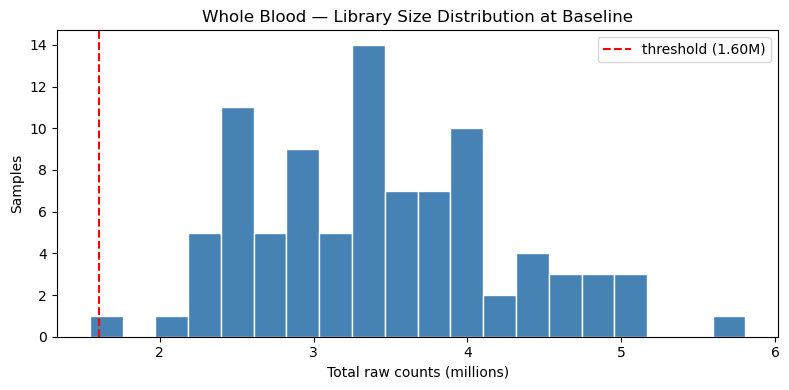

In [4]:
# Compute library sizes from raw X (before normalization)
lib_sizes = baseline.X.sum(axis=1)
if sp.issparse(baseline.X):
    lib_sizes = np.asarray(lib_sizes).flatten()

sample_ids = baseline.obs["sample.sampleKitGuid"].values

median_lib = np.median(lib_sizes)
mad_lib = np.median(np.abs(lib_sizes - median_lib))
lib_threshold = median_lib - 3 * mad_lib

low_lib_mask = lib_sizes < lib_threshold
n_flagged = low_lib_mask.sum()

print(f"Library size — median: {median_lib:,.0f}, MAD: {mad_lib:,.0f}")
print(f"Threshold (median − 3×MAD): {lib_threshold:,.0f}")
print(f"Samples flagged (wb.low_lib_flag): {n_flagged} / {len(lib_sizes)}")

# Plot library size distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(lib_sizes / 1e6, bins=20, color="steelblue", edgecolor="white")
ax.axvline(lib_threshold / 1e6, color="red", linestyle="--",
           label=f"threshold ({lib_threshold/1e6:.2f}M)")
ax.set_xlabel("Total raw counts (millions)")
ax.set_ylabel("Samples")
ax.set_title("Whole Blood — Library Size Distribution at Baseline")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "wholeblood_lib_size_qc.png", dpi=150)
plt.show()

## Stage 4 — Normalization & ssGSEA Pathway Scoring

### Normalization: CPM + log1p

Raw counts are normalized to counts per million (CPM) then log1p-transformed. CPM corrects for library size differences across samples. log1p compresses the dynamic range and stabilizes variance for high-count genes. Both steps are applied to a copy of the baseline AnnData — the original raw `.X` (used for the library size flag in Stage 3) is not modified.

`scanpy.pp.normalize_total(target_sum=1e6)` divides each row by its sum, then multiplies by 1e6.
`scanpy.pp.log1p()` applies log(x + 1) element-wise.

### Pathway scoring: ssGSEA over all 50 MSigDB Hallmark sets

ssGSEA (single-sample Gene Set Enrichment Analysis) ranks all genes by expression within each sample, then scores how coherently the genes of each Hallmark set cluster toward the top or bottom of that ranking. The result is a Normalized Enrichment Score (NES) per (sample × gene set). A positive NES means the pathway is coherently active in that sample relative to a null distribution; negative NES means suppressed.

All 50 MSigDB Hallmark sets are scored — no biological pre-selection. The node budget (5–10) is applied at BN fitting time by the group.

### Output format from gseapy 1.3.0

`gp.ssgsea(...).res2d` returns a long DataFrame with columns `Name` (sampleKitGuid), `Term` (Hallmark set name), `ES`, `NES`. Pivot to wide (samples × sets), apply `to_snake_case` + `wb.` prefix to column names, then set flagged samples' scores to NaN.

In [5]:
# --- CPM + log1p normalization ---
norm_adata = baseline.copy()
sc.pp.normalize_total(norm_adata, target_sum=1e6)
sc.pp.log1p(norm_adata)

print(f"Normalized X — min: {norm_adata.X.min():.3f}, max: {norm_adata.X.max():.3f}")

# Build genes x samples DataFrame for gseapy (rows=genes, cols=samples)
expr_df = pd.DataFrame(
    norm_adata.X.T,
    index=norm_adata.var_names,          # HGNC symbols
    columns=norm_adata.obs["sample.sampleKitGuid"].values,
)
print(f"Expression matrix for ssGSEA: {expr_df.shape} (genes × samples)")

# --- Fetch all 50 Hallmark sets ---
hallmark_sets = gp.get_library("MSigDB_Hallmark_2020", organism="Human")
print(f"\nHallmark sets loaded: {len(hallmark_sets)}")
# Confirm gene overlap for a representative set
sample_set = hallmark_sets["Interferon Gamma Response"]
overlap = sum(1 for g in sample_set if g in norm_adata.var_names)
print(f"'Interferon Gamma Response' overlap: {overlap}/{len(sample_set)} genes found in data")

# --- Run ssGSEA ---
print("\nRunning ssGSEA (may take 1–3 minutes)...")
ss = gp.ssgsea(
    data=expr_df,
    gene_sets=hallmark_sets,
    outdir=None,
    no_plot=True,
    threads=1,
    min_size=5,
)

# res2d is long: Name (sampleKitGuid), Term (gene set), ES, NES
print(f"res2d shape: {ss.res2d.shape}")
print(f"res2d columns: {list(ss.res2d.columns)}")

# Pivot to wide: samples x gene sets (NES values)
scores_wide = ss.res2d.pivot(index="Name", columns="Term", values="NES")
scores_wide.index.name = "sample.sampleKitGuid"
print(f"\nScores wide shape: {scores_wide.shape} (samples × Hallmark sets)")

# Apply wb. prefix and snake_case to column names
scores_wide.columns = [PREFIX + to_snake_case(c) for c in scores_wide.columns]

# Apply library size flag: set scores to NaN for flagged samples
flag_series = pd.Series(low_lib_mask, index=sample_ids, name="wb.low_lib_flag")
scores_wide = scores_wide.join(flag_series)

score_cols = [c for c in scores_wide.columns if c != "wb.low_lib_flag"]
if scores_wide["wb.low_lib_flag"].any():
    flagged_ids = scores_wide.index[scores_wide["wb.low_lib_flag"]].tolist()
    scores_wide.loc[flagged_ids, score_cols] = np.nan
    print(f"NaN applied to {len(flagged_ids)} flagged samples")
else:
    print("No samples flagged — all library sizes above threshold")

print(f"\nFinal scores_wide shape: {scores_wide.shape}")
scores_wide.head(3)

Normalized X — min: 0.000, max: 10.050
Expression matrix for ssGSEA: (58302, 91) (genes × samples)



Hallmark sets loaded: 50
'Interferon Gamma Response' overlap: 198/200 genes found in data

Running ssGSEA (may take 1–3 minutes)...


res2d shape: (4550, 4)
res2d columns: ['Name', 'Term', 'ES', 'NES']

Scores wide shape: (91, 50) (samples × Hallmark sets)
NaN applied to 1 flagged samples

Final scores_wide shape: (91, 51)


,wb.adipogenesis,wb.allograft_rejection,wb.androgen_response,wb.angiogenesis,wb.apical_junction,wb.apical_surface,wb.apoptosis,wb.bile_acid_metabolism,wb.cholesterol_homeostasis,wb.coagulation,...,wb.tnf_alpha_signaling_via_nf_kb,wb.uv_response_dn,wb.uv_response_up,wb.unfolded_protein_response,wb.wnt_beta_catenin_signaling,wb.xenobiotic_metabolism,wb.heme_metabolism,wb.mtorc1_signaling,wb.p53_pathway,wb.low_lib_flag
sample.sampleKitGuid,,,,,,,,,,,,,,,,,,,,,
KT00001,0.443840,0.456474,0.429651,0.126653,0.152134,0.188549,0.450163,0.198567,0.400218,0.096457,...,0.435225,0.301389,0.376253,0.552956,0.321468,0.246298,0.520441,0.537293,0.439280,False
KT00002,0.464475,0.477913,0.484345,0.185093,0.262403,0.271945,0.473478,0.261100,0.451951,0.186479,...,0.481032,0.320791,0.396097,0.552745,0.464041,0.304329,0.522465,0.556971,0.458756,False
KT00003,0.450737,0.462956,0.457436,0.108448,0.202751,0.197363,0.477210,0.239163,0.448336,0.104355,...,0.447768,0.289022,0.375552,0.555260,0.380639,0.242287,0.520134,0.555551,0.451287,False


## Stage 5 — Feature Selection / Node Budget

All 50 Hallmark pathway scores are retained in the output. The team's node budget for whole blood is **5–10 features**, to be selected at BN fitting time.

**No pre-selection is applied here.** All 50 sets are equally represented so that:
1. The BN structure can inform which pathways drive cross-modality edges.
2. The literature evaluation agent is not biased by pre-selection toward literature-expected results.

**Candidate subset for BN fitting (to be confirmed by group):**

| Column | Hallmark set | Rationale |
|--------|-------------|-----------|
| `wb.interferon_gamma_response` | HALLMARK_INTERFERON_GAMMA_RESPONSE | Type II IFN / antiviral; chronically elevated by CMV; increases with age |
| `wb.interferon_alpha_response` | HALLMARK_INTERFERON_ALPHA_RESPONSE | Type I IFN / innate antiviral; pDC-produced; distinct from IFN-γ axis |
| `wb.inflammatory_response` | HALLMARK_INFLAMMATORY_RESPONSE | TNF/IL-1/IL-6-driven inflammaging; elevated at baseline in older adults |
| `wb.tnf_alpha_signaling_via_nf_kb` | HALLMARK_TNFA_SIGNALING_VIA_NFKB | NFkB regulatory arm; distinct transcriptional driver from general inflammation |
| `wb.il2_stat5_signaling` | HALLMARK_IL2_STAT5_SIGNALING | T cell survival / homeostatic proliferation; declines with aging |
| `wb.il6_jak_stat3_signaling` | HALLMARK_IL6_JAK_STAT3_SIGNALING | IL-6/JAK/STAT3 axis; acute phase response; complement to inflammatory score |

All others are available in the output for group review.

Score features with >20% missing: 0 / 50


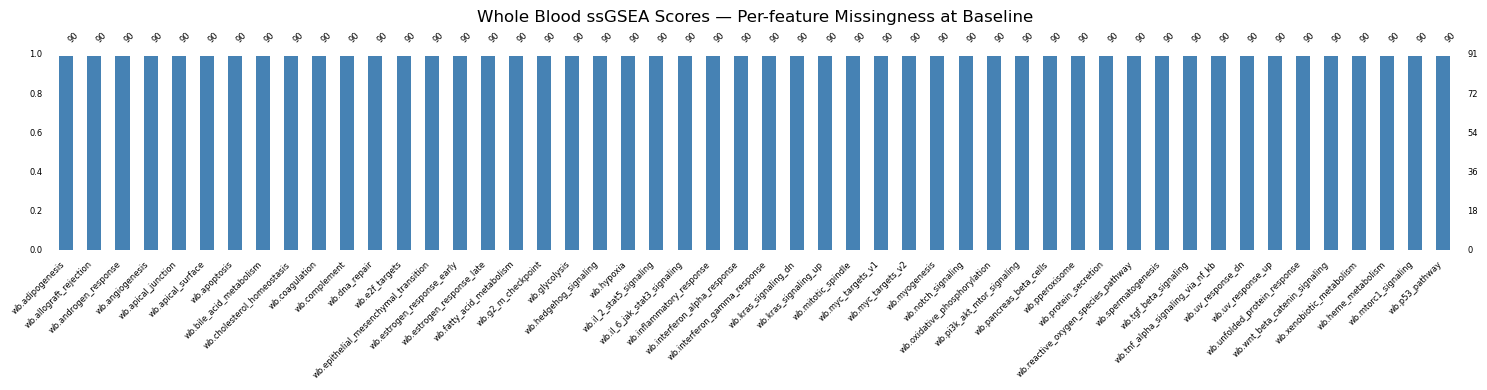


Total score features retained: 50
Node budget target: 5–10 (select at BN fitting time)

Score column names:
  wb.adipogenesis
  wb.allograft_rejection
  wb.androgen_response
  wb.angiogenesis
  wb.apical_junction
  wb.apical_surface
  wb.apoptosis
  wb.bile_acid_metabolism
  wb.cholesterol_homeostasis
  wb.coagulation
  wb.complement
  wb.dna_repair
  wb.e2f_targets
  wb.epithelial_mesenchymal_transition
  wb.estrogen_response_early
  wb.estrogen_response_late
  wb.fatty_acid_metabolism
  wb.g2_m_checkpoint
  wb.glycolysis
  wb.hedgehog_signaling
  wb.heme_metabolism
  wb.hypoxia
  wb.il_2_stat5_signaling
  wb.il_6_jak_stat3_signaling
  wb.inflammatory_response
  wb.interferon_alpha_response
  wb.interferon_gamma_response
  wb.kras_signaling_dn
  wb.kras_signaling_up
  wb.mitotic_spindle
  wb.mtorc1_signaling
  wb.myc_targets_v1
  wb.myc_targets_v2
  wb.myogenesis
  wb.notch_signaling
  wb.oxidative_phosphorylation
  wb.p53_pathway
  wb.pancreas_beta_cells
  wb.pi3k_akt_mtor_signaling

In [6]:
# Missingness audit on score columns
miss_summary = flag_missingness(scores_wide[score_cols])
n_candidates = miss_summary["exclude_candidate"].sum()
print(f"Score features with >20% missing: {n_candidates} / {len(score_cols)}")
if n_candidates > 0:
    print(miss_summary[miss_summary["exclude_candidate"]].to_string())

# Missingness bar chart
fig, ax = plt.subplots(figsize=(max(12, len(score_cols) * 0.3), 4))
msno.bar(scores_wide[score_cols], ax=ax, fontsize=6, color="steelblue")
ax.set_title("Whole Blood ssGSEA Scores — Per-feature Missingness at Baseline")
plt.tight_layout()
plt.savefig(FIGURES / "wholeblood_score_missingness.png", dpi=150)
plt.show()

print(f"\nTotal score features retained: {len(score_cols)}")
print(f"Node budget target: 5–10 (select at BN fitting time)")
print(f"\nScore column names:")
for c in sorted(score_cols):
    print(f"  {c}")

## Stage 6 — Export

In [7]:
# Build final wide DataFrame with canonical column order
id_cols = ["subject.subjectGuid", "sample.sampleKitGuid"]

# Attach subject.subjectGuid from baseline obs
guid_map = (
    baseline.obs[["sample.sampleKitGuid", "subject.subjectGuid"]]
    .drop_duplicates()
    .set_index("sample.sampleKitGuid")
)
wide = scores_wide.reset_index()
wide = wide.join(
    guid_map, on="sample.sampleKitGuid"
)
wide = wide[id_cols + sorted(score_cols) + ["wb.low_lib_flag"]]

print(f"Final output shape: {wide.shape}")
print(f"  {len(score_cols)} score columns (50 Hallmark sets)")
print(f"  1 flag column (wb.low_lib_flag)")

enforce_export_contract(wide, prefix=PREFIX)
output_path = write_processed(wide, modality_name="wholeblood", output_dir=str(PROCESSED))
print(f"\nWritten: {output_path}")

# Build manifest entries
manifest_entries = []
for col in sorted(score_cols):
    set_name_snake = col[len(PREFIX):]  # strip "wb."
    manifest_entries.append({
        "feature_name": col,
        "modality": "whole_blood",
        "source_column": "X (CPM + log1p normalized, then ssGSEA NES)",
        "rationale": (
            f"ssGSEA Normalized Enrichment Score for MSigDB Hallmark set "
            f"'{set_name_snake.replace('_', ' ').title()}' "
            f"computed over all 91 baseline samples (KT00030 Replicate 2 dropped). "
            f"All 50 Hallmark sets retained; 5-10 selected for BN fitting by group. "
            f"Included."
        ),
    })

manifest_entries.append({
    "feature_name": "wb.low_lib_flag",
    "modality": "whole_blood",
    "source_column": "X row sum (total raw counts)",
    "rationale": (
        f"QC flag: True when total raw read count < median - 3xMAD "
        f"(threshold: {lib_threshold:,.0f}). "
        f"Flagged samples' ssGSEA scores are set to NaN."
    ),
})

append_manifest(manifest_entries, str(PROCESSED / "feature_manifest.csv"))
print(f"Manifest entries written: {len(manifest_entries)}")
print("\nManifest preview (last 5 rows):")
pd.read_csv(PROCESSED / "feature_manifest.csv").tail(5)

Final output shape: (91, 53)
  50 score columns (50 Hallmark sets)
  1 flag column (wb.low_lib_flag)

Written: ..\data\processed\wholeblood_baseline_wide.csv
Manifest entries written: 51

Manifest preview (last 5 rows):


,feature_name,modality,source_column,rationale
1376,wb.uv_response_dn,whole_blood,"X (CPM + log1p normalized, then ssGSEA NES)",ssGSEA Normalized Enrichment Score for MSigDB ...
1377,wb.uv_response_up,whole_blood,"X (CPM + log1p normalized, then ssGSEA NES)",ssGSEA Normalized Enrichment Score for MSigDB ...
1378,wb.wnt_beta_catenin_signaling,whole_blood,"X (CPM + log1p normalized, then ssGSEA NES)",ssGSEA Normalized Enrichment Score for MSigDB ...
1379,wb.xenobiotic_metabolism,whole_blood,"X (CPM + log1p normalized, then ssGSEA NES)",ssGSEA Normalized Enrichment Score for MSigDB ...
1380,wb.low_lib_flag,whole_blood,X row sum (total raw counts),QC flag: True when total raw read count < medi...
